**Objective**
To build a convolution autoencoder (CAE) that compresses facial images into a lower - dimensional latent representation and reconstructs them with minimal loss of information.

**Purpose**
A convolutional Autoencoder is an unsupervised deep learning model used for:
Image Compression Image Reconstruction Features Extraction Dimensionality Reduction
The encoder learns a compressed representation (latent space), while the decoder reconstructs the original image from the compressed represenalation

In [157]:
#libraries
import os # math calcul, access file
import shutil # visualization
import numpy as np

import matplotlib.pyplot as plt
import tensorflow as tf # use in deep learning

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

In [158]:
! pip install -q kaggle

In [159]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [160]:
# Create a Smaller Dataset (5000 Images)
source_folder = os.path.join(path,"img_align_celeba","img_align_celeba")
destination_folder = "celeba_small/faces"
os.makedirs(destination_folder,exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]
for image in images:
  shutil.copy(
      os.path.join(source_folder,image),
      destination_folder
      )
  print("copied",len(images),"images")

copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 images
copied 5000 

In [161]:
#Data Preprocessing

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32

In [162]:
datagen= ImageDataGenerator(rescale=1./255,validation_split=0.2)

In [163]:
#load dataset

train_generator= datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [164]:
#load dataset

validation_generator= datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


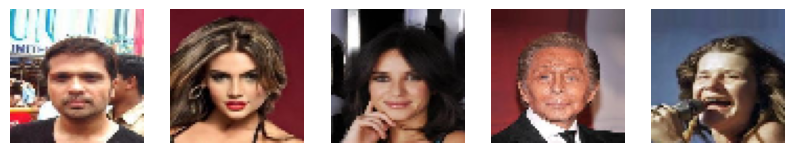

In [165]:
#Display Sample Images
images, _ = next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(images[i])
  plt.axis("off")
plt.show()

In [166]:
#encoder
input_img = Input(shape=(64,64,3))
x = Conv2D(32,(3,3),
           activation="relu",
           padding="same"
)(input_img)
x = MaxPooling2D((2,2),padding="same")(x)
x = Conv2D(64,(3,3),
           activation="relu",
           padding="same"
)(x)
encoded = MaxPooling2D((2,2),padding="same")(x)

In [167]:
#Decoder
x = Conv2D(64,(3,3),
           activation="relu",
           padding="same"
)(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32,(3,3),
           activation="relu",
           padding="same"
)(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(3,(3,3),
                 activation="sigmoid",
                 padding="same"
)(x)

In [168]:
# Create Model
autoencoder = Model(
    input_img,
    decoded
)

In [169]:
#compile model
autoencoder.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy'
)

In [170]:
#comiple model
from tensorflow.keras.optimizers import Adam
op=Adam(learning_rate=0.1)
autoencoder.compile(optimizer=op,loss='mse')

In [171]:
# model summary
autoencoder.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_12 (UpSampling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_13 (UpSampling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [152]:
# train model
history = autoencoder.fit(
    train_generator,
    validation_data =  validation_generator,
    epochs =5
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - loss: 0.0202 - val_loss: 0.0090
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0079 - val_loss: 0.0065
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0066 - val_loss: 0.0059
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0060 - val_loss: 0.0060
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0057 - val_loss: 0.0049


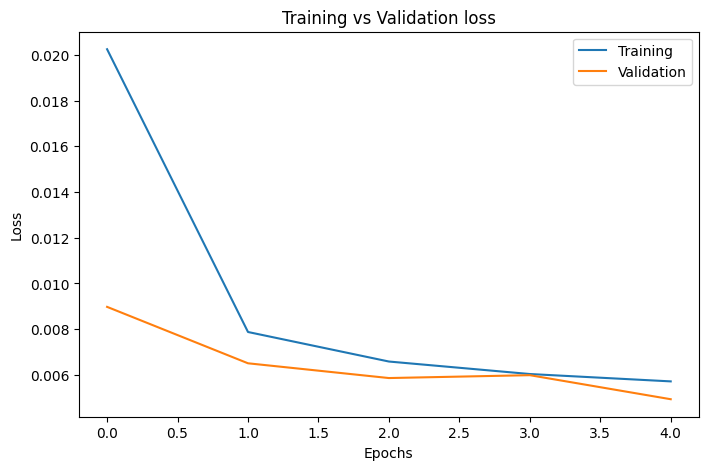

In [153]:
#Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation loss")
plt.legend(["Training","Validation"])
plt.show()

In [154]:
# evaluate model
loss = autoencoder.evaluate(validation_generator)
print("Validation Loss : ", loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0049
Validation Loss :  0.004936851095408201


In [155]:
#reconstruct images
images, _ = next(validation_generator)
reconstructed_images = autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 626ms/step


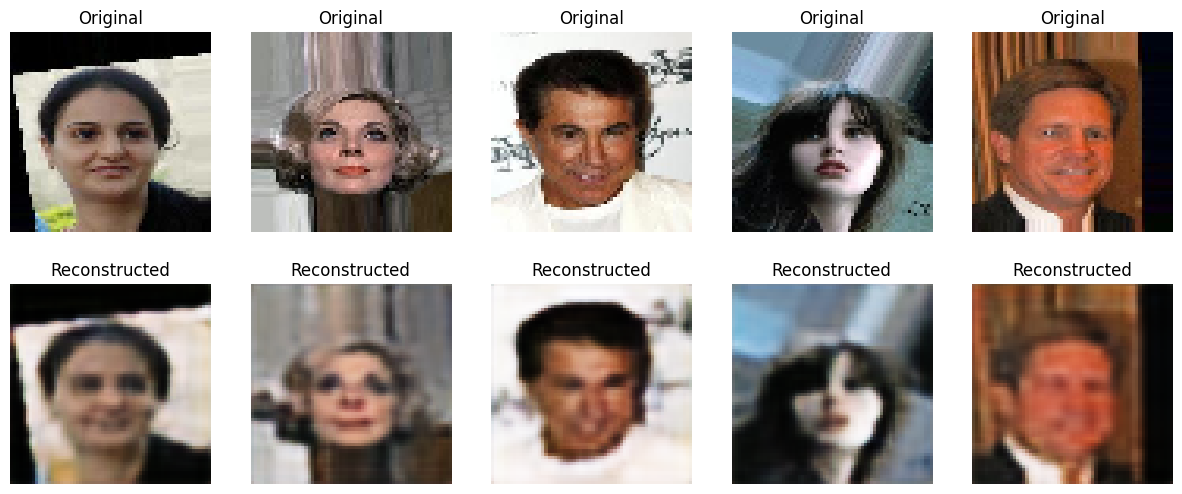

In [156]:
#display results
n = 5
plt.figure(figsize=(15,6))
for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.title("Original")
  plt.axis("off")
  plt.subplot(2,n,i+1+n)
  plt.imshow(reconstructed_images[i])
  plt.title("Reconstructed")
  plt.axis("off")
plt.show()